In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context  # fix de certificados en macOS

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader

from torchvision import transforms
from torchvision.datasets import MNIST

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 23183
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = MNIST(root="./data", train=False, download=True, transform=transform)

val_fraction = 0.15
n_val = int(len(train_dataset) * val_fraction)
n_train = len(train_dataset) - n_val
generator = torch.Generator().manual_seed(SEED)
train_split, val_split = random_split(train_dataset, [n_train, n_val], generator=generator)

BATCH_SIZE = 64
train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_dataset)}")

Usando device: mps
Train: 51000 | Val: 9000 | Test: 10000


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_metrics(model, loader, device):
    """Calcula accuracy, precision, recall, f1 (macro) y devuelve también y_true/y_pred
    para poder construir la matriz de confusión."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    return metrics, y_true, y_pred


def train_model(model, train_loader, val_loader, epochs, lr, device,
                 weight_decay=0.0, optimizer_name="adam", verbose=True):
    """Entrena `model` y devuelve el historial de pérdidas por epoch + tiempo total."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizer_name}")

    history = {"train_loss": [], "val_loss": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_running_loss += loss.item() * x.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"  Epoch {epoch+1}/{epochs} — train_loss: {train_loss:.4f} — val_loss: {val_loss:.4f}")

    elapsed = time.time() - start_time
    return history, elapsed

# MLP

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=False, num_classes=10):
        super().__init__()
        layers = [nn.Flatten()]
        in_features = 28 * 28
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


_test_model = MLP()
_test_out = _test_model(torch.randn(4, 1, 28, 28))
print(f"Output shape: {_test_out.shape}")  
print(f"Parámetros: {count_parameters(_test_model):,}")

Output shape: torch.Size([4, 10])
Parámetros: 235,146


## Hiperparámetros

In [6]:
mlp_configs = [
    {
        "name": "MLP-baseline",
        "hidden_sizes": (128,),
        "dropout": 0.0,
        "use_batchnorm": False,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
    {
        "name": "MLP-mas-capacidad",
        "hidden_sizes": (512, 256),
        "dropout": 0.0,
        "use_batchnorm": False,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
    {
        "name": "MLP-regularizado",
        "hidden_sizes": (512, 256),
        "dropout": 0.3,
        "use_batchnorm": True,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
]

mlp_results = []

for cfg in mlp_configs:
    print(f"\n=== Entrenando {cfg['name']} ===")
    model = MLP(hidden_sizes=cfg["hidden_sizes"], dropout=cfg["dropout"], use_batchnorm=cfg["use_batchnorm"])
    n_params = count_parameters(model)

    history, elapsed = train_model(
        model, train_loader, val_loader,
        epochs=cfg["epochs"], lr=cfg["lr"], device=device,
        optimizer_name=cfg["optimizer_name"],
    )
    val_metrics, _, _ = evaluate_metrics(model, val_loader, device)

    mlp_results.append({
        "config": cfg,
        "model": model,
        "history": history,
        "elapsed_sec": elapsed,
        "n_params": n_params,
        "val_metrics": val_metrics,
    })

    print(f"  Parámetros: {n_params:,} | Tiempo: {elapsed:.1f}s")
    print(f"  Val metrics: {val_metrics}")


=== Entrenando MLP-baseline ===
  Epoch 1/10 — train_loss: 0.2858 — val_loss: 0.1624
  Epoch 2/10 — train_loss: 0.1281 — val_loss: 0.1358
  Epoch 3/10 — train_loss: 0.0879 — val_loss: 0.1132
  Epoch 4/10 — train_loss: 0.0645 — val_loss: 0.0927
  Epoch 5/10 — train_loss: 0.0527 — val_loss: 0.0930
  Epoch 6/10 — train_loss: 0.0410 — val_loss: 0.0875
  Epoch 7/10 — train_loss: 0.0329 — val_loss: 0.0847
  Epoch 8/10 — train_loss: 0.0276 — val_loss: 0.0854
  Epoch 9/10 — train_loss: 0.0237 — val_loss: 0.0946
  Epoch 10/10 — train_loss: 0.0206 — val_loss: 0.0930
  Parámetros: 101,770 | Tiempo: 43.9s
  Val metrics: {'accuracy': 0.9751111111111112, 'precision': 0.9751787681879283, 'recall': 0.9748100790056702, 'f1': 0.9749209325893962}

=== Entrenando MLP-mas-capacidad ===
  Epoch 1/10 — train_loss: 0.2206 — val_loss: 0.1219
  Epoch 2/10 — train_loss: 0.0915 — val_loss: 0.0954
  Epoch 3/10 — train_loss: 0.0633 — val_loss: 0.0849
  Epoch 4/10 — train_loss: 0.0502 — val_loss: 0.0944
  Epoch 5/1

## Curvas de pérdida

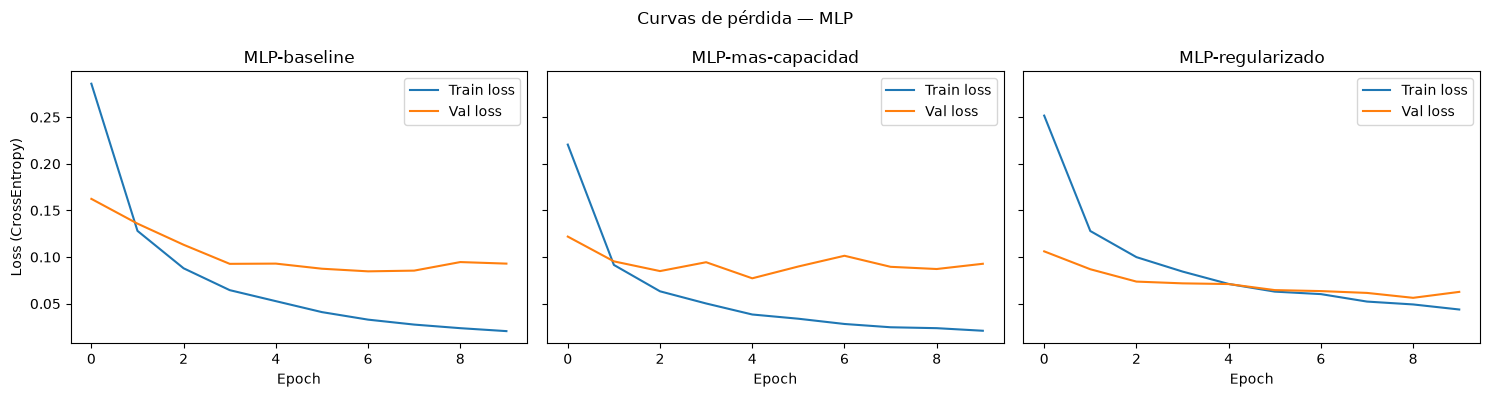

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, result in zip(axes, mlp_results):
    h = result["history"]
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(result["config"]["name"])
    ax.set_xlabel("Epoch")
    ax.legend()
axes[0].set_ylabel("Loss (CrossEntropy)")
plt.suptitle("Curvas de pérdida — MLP")
plt.tight_layout()
plt.show()

# CNN

In [8]:
class CNN(nn.Module):
    def __init__(self, conv_channels=(32, 64), fc_hidden=128, dropout=0.0, num_classes=10):
        super().__init__()
        conv_layers = []
        in_channels = 1
        for out_channels in conv_channels:
            conv_layers += [
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            ]
            in_channels = out_channels
        self.conv = nn.Sequential(*conv_layers)

        # Cada MaxPool2d(2,2) reduce alto/ancho a la mitad
        spatial_size = 28 // (2 ** len(conv_channels))
        flat_features = in_channels * spatial_size * spatial_size

        fc_layers = [nn.Flatten(), nn.Linear(flat_features, fc_hidden), nn.ReLU()]
        if dropout > 0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(fc_hidden, num_classes))
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

_test_cnn = CNN()
_test_out = _test_cnn(torch.randn(4, 1, 28, 28))
print(f"Output shape: {_test_out.shape}")  
print(f"Parámetros: {count_parameters(_test_cnn):,}")

Output shape: torch.Size([4, 10])
Parámetros: 421,834


## Hiperparámetros

In [9]:
cnn_configs = [
    {
        "name": "CNN-baseline",
        "conv_channels": (16, 32),
        "fc_hidden": 128,
        "dropout": 0.0,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
    {
        "name": "CNN-mas-filtros",
        "conv_channels": (32, 64),
        "fc_hidden": 128,
        "dropout": 0.0,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
    {
        "name": "CNN-regularizada",
        "conv_channels": (32, 64),
        "fc_hidden": 128,
        "dropout": 0.3,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
]

cnn_results = []

for cfg in cnn_configs:
    print(f"\n=== Entrenando {cfg['name']} ===")
    model = CNN(conv_channels=cfg["conv_channels"], fc_hidden=cfg["fc_hidden"], dropout=cfg["dropout"])
    n_params = count_parameters(model)

    history, elapsed = train_model(
        model, train_loader, val_loader,
        epochs=cfg["epochs"], lr=cfg["lr"], device=device,
        optimizer_name=cfg["optimizer_name"],
    )
    val_metrics, _, _ = evaluate_metrics(model, val_loader, device)

    cnn_results.append({
        "config": cfg,
        "model": model,
        "history": history,
        "elapsed_sec": elapsed,
        "n_params": n_params,
        "val_metrics": val_metrics,
    })

    print(f"  Parámetros: {n_params:,} | Tiempo: {elapsed:.1f}s")
    print(f"  Val metrics: {val_metrics}")


=== Entrenando CNN-baseline ===
  Epoch 1/10 — train_loss: 0.1389 — val_loss: 0.0703
  Epoch 2/10 — train_loss: 0.0491 — val_loss: 0.0466
  Epoch 3/10 — train_loss: 0.0349 — val_loss: 0.0367
  Epoch 4/10 — train_loss: 0.0271 — val_loss: 0.0404
  Epoch 5/10 — train_loss: 0.0232 — val_loss: 0.0420
  Epoch 6/10 — train_loss: 0.0186 — val_loss: 0.0455
  Epoch 7/10 — train_loss: 0.0152 — val_loss: 0.0358
  Epoch 8/10 — train_loss: 0.0127 — val_loss: 0.0507
  Epoch 9/10 — train_loss: 0.0110 — val_loss: 0.0599
  Epoch 10/10 — train_loss: 0.0114 — val_loss: 0.0428
  Parámetros: 207,018 | Tiempo: 78.0s
  Val metrics: {'accuracy': 0.9903333333333333, 'precision': 0.9902322908573528, 'recall': 0.9902501760181963, 'f1': 0.990231173857679}

=== Entrenando CNN-mas-filtros ===
  Epoch 1/10 — train_loss: 0.1293 — val_loss: 0.0664
  Epoch 2/10 — train_loss: 0.0483 — val_loss: 0.0458
  Epoch 3/10 — train_loss: 0.0343 — val_loss: 0.0454
  Epoch 4/10 — train_loss: 0.0282 — val_loss: 0.0538
  Epoch 5/10 —

## Curva de pérdida

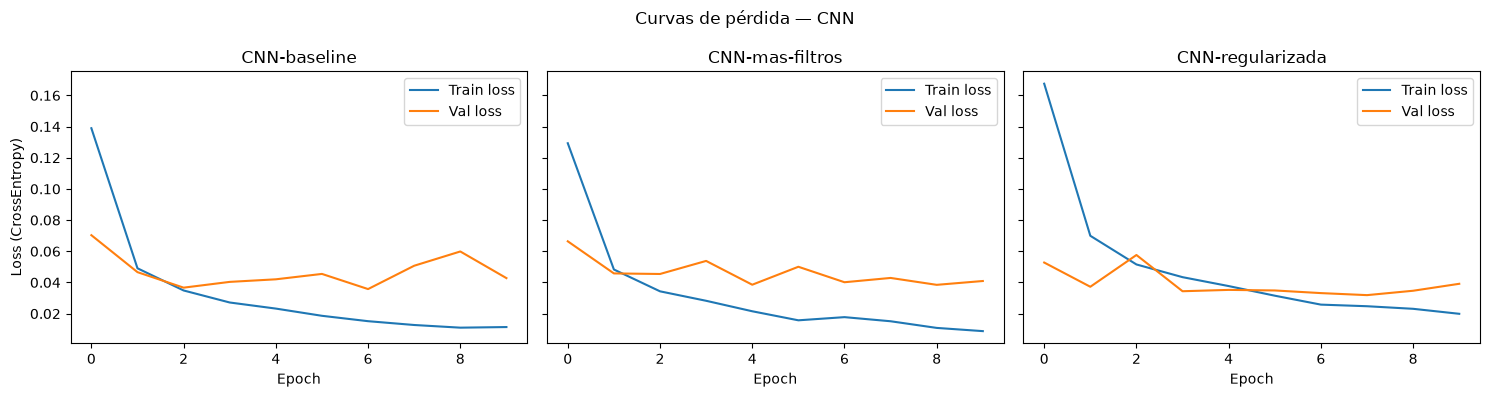

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, result in zip(axes, cnn_results):
    h = result["history"]
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(result["config"]["name"])
    ax.set_xlabel("Epoch")
    ax.legend()
axes[0].set_ylabel("Loss (CrossEntropy)")
plt.suptitle("Curvas de pérdida — CNN")
plt.tight_layout()
plt.show()

# Comparación

## Selección de la mejor configuración por arquitectura

In [11]:
def pick_best(results, metric="accuracy"):
    return max(results, key=lambda r: r["val_metrics"][metric])

best_mlp = pick_best(mlp_results)
best_cnn = pick_best(cnn_results)

print(f"Mejor MLP: {best_mlp['config']['name']} — val_accuracy = {best_mlp['val_metrics']['accuracy']:.4f}")
print(f"Mejor CNN: {best_cnn['config']['name']} — val_accuracy = {best_cnn['val_metrics']['accuracy']:.4f}")

Mejor MLP: MLP-regularizado — val_accuracy = 0.9826
Mejor CNN: CNN-regularizada — val_accuracy = 0.9916


## Evaluación final sobre el conjunto Test

In [12]:
test_metrics_mlp, y_true_mlp, y_pred_mlp = evaluate_metrics(best_mlp["model"], test_loader, device)
test_metrics_cnn, y_true_cnn, y_pred_cnn = evaluate_metrics(best_cnn["model"], test_loader, device)

print("=== MLP (mejor config) — métricas en TEST ===")
for k, v in test_metrics_mlp.items():
    print(f"  {k}: {v:.4f}")

print("\n=== CNN (mejor config) — métricas en TEST ===")
for k, v in test_metrics_cnn.items():
    print(f"  {k}: {v:.4f}")

=== MLP (mejor config) — métricas en TEST ===
  accuracy: 0.9815
  precision: 0.9815
  recall: 0.9814
  f1: 0.9814

=== CNN (mejor config) — métricas en TEST ===
  accuracy: 0.9916
  precision: 0.9915
  recall: 0.9915
  f1: 0.9915


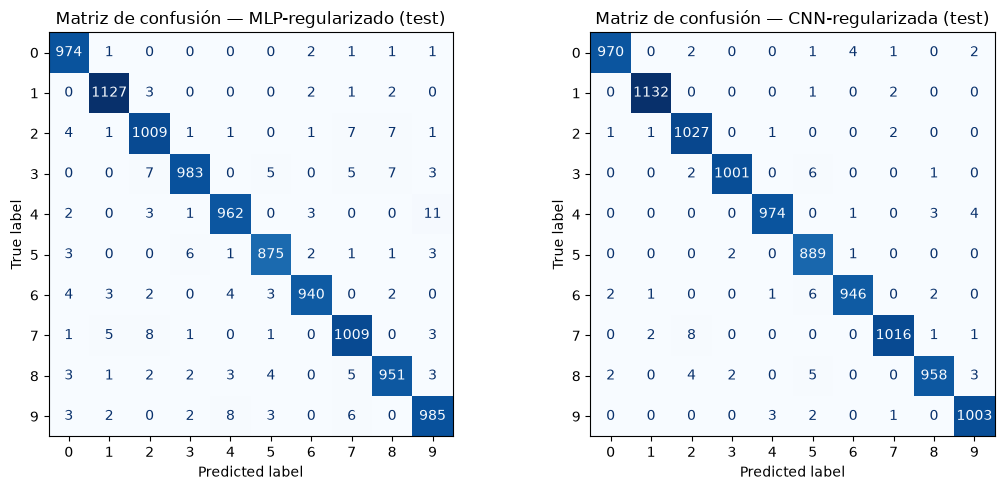

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

cm_mlp = confusion_matrix(y_true_mlp, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=range(10)).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matriz de confusión — {best_mlp['config']['name']} (test)")

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=range(10)).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Matriz de confusión — {best_cnn['config']['name']} (test)")

plt.tight_layout()
plt.show()

## Comparación Arquitecturas

In [14]:
comparison_df = pd.DataFrame([
    {
        "Arquitectura": "MLP",
        "Configuración": best_mlp["config"]["name"],
        "Parámetros entrenables": best_mlp["n_params"],
        "Tiempo entrenamiento (s)": round(best_mlp["elapsed_sec"], 1),
        "Accuracy (test)": round(test_metrics_mlp["accuracy"], 4),
        "Precision (test)": round(test_metrics_mlp["precision"], 4),
        "Recall (test)": round(test_metrics_mlp["recall"], 4),
        "F1 (test)": round(test_metrics_mlp["f1"], 4),
    },
    {
        "Arquitectura": "CNN",
        "Configuración": best_cnn["config"]["name"],
        "Parámetros entrenables": best_cnn["n_params"],
        "Tiempo entrenamiento (s)": round(best_cnn["elapsed_sec"], 1),
        "Accuracy (test)": round(test_metrics_cnn["accuracy"], 4),
        "Precision (test)": round(test_metrics_cnn["precision"], 4),
        "Recall (test)": round(test_metrics_cnn["recall"], 4),
        "F1 (test)": round(test_metrics_cnn["f1"], 4),
    },
])

comparison_df

,Arquitectura,Configuración,Parámetros entrenables,Tiempo entrenamiento (s),Accuracy (test),Precision (test),Recall (test),F1 (test)
0,MLP,MLP-regularizado,537354,52.0,0.9815,0.9815,0.9814,0.9814
1,CNN,CNN-regularizada,421834,84.0,0.9916,0.9915,0.9915,0.9915


## Parámetros vs Accuracy

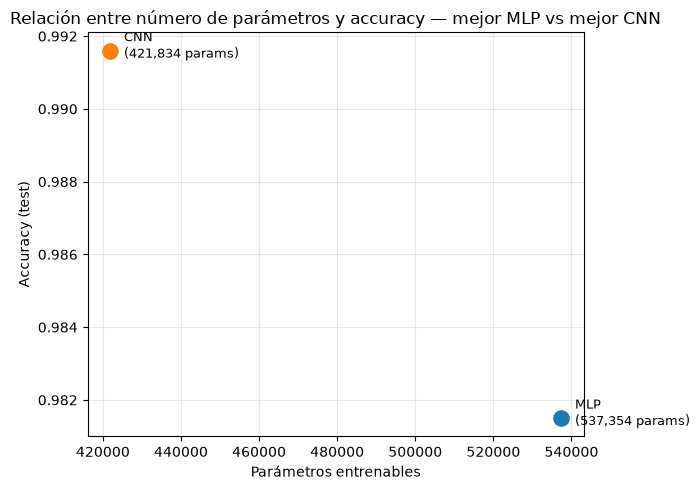

In [15]:
plt.figure(figsize=(7, 5))
for _, row in comparison_df.iterrows():
    plt.scatter(row["Parámetros entrenables"], row["Accuracy (test)"], s=120)
    plt.annotate(
        f"{row['Arquitectura']}\n({row['Parámetros entrenables']:,} params)",
        (row["Parámetros entrenables"], row["Accuracy (test)"]),
        textcoords="offset points", xytext=(10, -5), fontsize=9,
    )
plt.xlabel("Parámetros entrenables")
plt.ylabel("Accuracy (test)")
plt.title("Relación entre número de parámetros y accuracy — mejor MLP vs mejor CNN")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()